In [1]:
from transformers import AutoTokenizer, PaliGemmaForConditionalGeneration
from transformers import AutoProcessor

/home/ostrich/anaconda3/envs/vlms/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
processor = AutoProcessor.from_pretrained("google/paligemma-3b-pt-224")

In [3]:
model = PaliGemmaForConditionalGeneration.from_pretrained("google/paligemma-3b-pt-224", cache_dir="paligemma-3b-pt-224")

`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.
Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.13it/s]


In [4]:
from PIL import Image

prompt = "caption en"
image = Image.open("../test_images/cyber-kitty.jpg")

inputs = processor(image, prompt, return_tensors="pt")
output = model.generate(**inputs, max_new_tokens=256, temperature=0.8, top_p=0.95, do_sample=True)

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


In [5]:
output.shape

torch.Size([1, 271])

In [6]:
tokens = processor.tokenizer.decode(output.squeeze(), skip_special_tokens=True)
tokens

'caption en\nanimal in a pink hoodie and with cool sunglasses .'

In [7]:
from processing_paligemma import PaliGemmaProcessor

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google/paligemma-3b-pt-224")

processor = PaliGemmaProcessor(tokenizer=tokenizer, num_image_tokens=(224//14) ** 2, image_size=224)

In [9]:
my_inputs = processor(text=[prompt], images=[image], return_tensors="pt")

In [10]:
my_inputs

{'pixel_values': tensor([[[[ 0.9843,  0.9922,  0.9922,  ..., -0.9922, -0.9922, -0.9922],
           [ 0.9843,  0.9922,  0.9922,  ..., -0.9922, -0.9922, -0.9922],
           [ 0.9922,  1.0000,  0.9922,  ..., -0.9922, -1.0000, -1.0000],
           ...,
           [ 0.9451,  0.9373,  0.8902,  ..., -0.6314, -0.8824, -0.9059],
           [ 0.9765,  0.9765,  0.9373,  ..., -0.7098, -0.8824, -0.6314],
           [ 0.9451,  0.9608,  0.9216,  ..., -0.7961, -0.5608, -0.5451]],
 
          [[ 0.7647,  0.7725,  0.7647,  ...,  0.3725,  0.3725,  0.3725],
           [ 0.7725,  0.7804,  0.7725,  ...,  0.4275,  0.4196,  0.4196],
           [ 0.7961,  0.8039,  0.7882,  ...,  0.4745,  0.4745,  0.4745],
           ...,
           [-0.7333, -0.7255, -0.7804,  ..., -0.7569, -0.9137, -0.9216],
           [-0.7176, -0.6078, -0.5843,  ..., -0.8275, -0.9373, -0.7098],
           [-0.9059, -0.7255, -0.5608,  ..., -0.9059, -0.7020, -0.7333]],
 
          [[ 0.4510,  0.4588,  0.4510,  ...,  0.6471,  0.6471,  0.6471

In [11]:
assert my_inputs["pixel_values"].shape == inputs["pixel_values"].shape
assert my_inputs["pixel_values"].equal(inputs["pixel_values"])

In [12]:
# code snippet that checks the hidden states of the paligemma model of huggingface

# single forward pass
output = model.forward(**inputs, output_attentions=True, output_hidden_states=True)

# take the hidden states
for i, h_state in enumerate(output["hidden_states"]):
    print(f"Layer {i + 1}: ")
    print("Hidden state min: {}, max: {}".format(h_state.min(), h_state.max()))

GemmaModel is using GemmaSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Layer 1: 
Hidden state min: -472.79058837890625, max: 289.706298828125
Layer 2: 
Hidden state min: -510.2797546386719, max: 167.00872802734375
Layer 3: 
Hidden state min: -518.4964599609375, max: 167.76109313964844
Layer 4: 
Hidden state min: -527.4197387695312, max: 163.01023864746094
Layer 5: 
Hidden state min: -534.94140625, max: 174.08006286621094
Layer 6: 
Hidden state min: -543.0319213867188, max: 185.5924835205078
Layer 7: 
Hidden state min: -554.0967407226562, max: 203.19146728515625
Layer 8: 
Hidden state min: -564.5490112304688, max: 257.9317321777344
Layer 9: 
Hidden state min: -1529.469482421875, max: 902.5411376953125
Layer 10: 
Hidden state min: -1833.8878173828125, max: 1159.302001953125
Layer 11: 
Hidden state min: -1834.77099609375, max: 1227.1318359375
Layer 12: 
Hidden state min: -1836.2293701171875, max: 1306.2015380859375
Layer 13: 
Hidden state min: -1835.225830078125, max: 1407.923095703125
Layer 14: 
Hidden state min: -1837.2196044921875, max: 1449.9593505859375

In [15]:
# Check our implementation
import sys
sys.path.append("../")
from modelling_paligemma import PaliGemmaForConditionalGeneration as my_paligemma
from modelling_paligemma import PaliGemmaConfig as my_config
from model_utils import load_hf_model
import json

# load our model
my_model, tokenizer = load_hf_model(model_path="../paligemma-3b-pt-224", model_id="google/paligemma-3b-pt-224", device="cpu")


Missing Keys required by the model: 
['language_model.lm_head.weight']
Unexpected keys recieved to the model: 
[]


In [16]:
my_outputs = my_model.forward(**inputs, output_hidden_states=True, output_attentions=True)

# take the hidden states
for i, h_state in enumerate(my_outputs["hidden_states"]):
    print(f"Layer {i + 1}: ")
    print("Hidden state min: {}, max: {}".format(h_state.min(), h_state.max()))

Layer 1: 
Hidden state min: -472.79058837890625, max: 289.706298828125
Layer 2: 
Hidden state min: -510.2797546386719, max: 167.00869750976562
Layer 3: 
Hidden state min: -518.4964599609375, max: 167.7610626220703
Layer 4: 
Hidden state min: -527.4197387695312, max: 163.01022338867188
Layer 5: 
Hidden state min: -534.94140625, max: 174.08004760742188
Layer 6: 
Hidden state min: -543.0319213867188, max: 185.59246826171875
Layer 7: 
Hidden state min: -554.0967407226562, max: 203.19146728515625
Layer 8: 
Hidden state min: -564.5490112304688, max: 257.9317321777344
Layer 9: 
Hidden state min: -1529.469970703125, max: 902.5413818359375
Layer 10: 
Hidden state min: -1833.888427734375, max: 1159.30224609375
Layer 11: 
Hidden state min: -1834.7716064453125, max: 1227.132080078125
Layer 12: 
Hidden state min: -1836.22998046875, max: 1306.2017822265625
Layer 13: 
Hidden state min: -1835.2264404296875, max: 1407.92333984375
Layer 14: 
Hidden state min: -1837.22021484375, max: 1449.95947265625
Lay

In [17]:
# check the image features
# NOTE: There is no problem with the image features.

image_features = output["image_hidden_states"]
my_image_features = output["image_hidden_states"]

assert my_image_features.shape == my_image_features.shape

# Image feature stats
print("Image features statistics: \n")
print("feature min: {}, max: {}, mean: {}, std: {}".format(image_features.min(), image_features.max(), image_features.mean(), image_features.std()))
print(
    "my feature min: {}, max: {}, mean: {}, std: {}".format(
        my_image_features.min(),
        my_image_features.max(),
        my_image_features.mean(),
        my_image_features.std(),
    )
)

print("Are my_image_features equal to hf?: {}".format(image_features.equal(my_image_features)))

Image features statistics: 

feature min: -0.21327081322669983, max: 0.2843499779701233, mean: 0.00039246262167580426, std: 0.024373410269618034
my feature min: -0.21327081322669983, max: 0.2843499779701233, mean: 0.00039246262167580426, std: 0.024373410269618034
Are my_image_features equal to hf?: True


In [18]:
# view attentions
attentions = output["attentions"]
my_attentions = my_outputs["attentions"]

print("Attention Statistics comparision: \n")
for i, (attn, my_attn) in enumerate(zip(attentions, my_attentions)):
    print(
        "HF Attention, min: {}, max: {}, mean: {}, std: {}".format(
            attn.min(), attn.max(), attn.mean(), attn.std()
        )
    )
    print(
        "My Attentions, min: {}, max: {}, mean: {}, std: {}".format(
            my_attn.min(), my_attn.max(), my_attn.mean(), my_attn.std()
        )
    )


Attention Statistics comparision: 

HF Attention, min: 2.202379630578767e-17, max: 0.9999948740005493, mean: 0.003846153849735856, std: 0.047890737652778625
My Attentions, min: 2.20231262894915e-17, max: 0.9999948740005493, mean: 0.003846153849735856, std: 0.047890737652778625
HF Attention, min: 4.5894239519839175e-08, max: 0.9852629899978638, mean: 0.003846153849735856, std: 0.04641231521964073
My Attentions, min: 4.5894420708236794e-08, max: 0.9852628707885742, mean: 0.003846153849735856, std: 0.04641231521964073
HF Attention, min: 2.1151400630969874e-09, max: 0.9753950238227844, mean: 0.003846153849735856, std: 0.03946144878864288
My Attentions, min: 2.115179809081269e-09, max: 0.9753949046134949, mean: 0.003846153849735856, std: 0.03946144878864288
HF Attention, min: 6.779077299512437e-10, max: 0.9654793739318848, mean: 0.0038461533840745687, std: 0.035793788731098175
My Attentions, min: 6.779007910573398e-10, max: 0.9654794931411743, mean: 0.003846153849735856, std: 0.035793803632

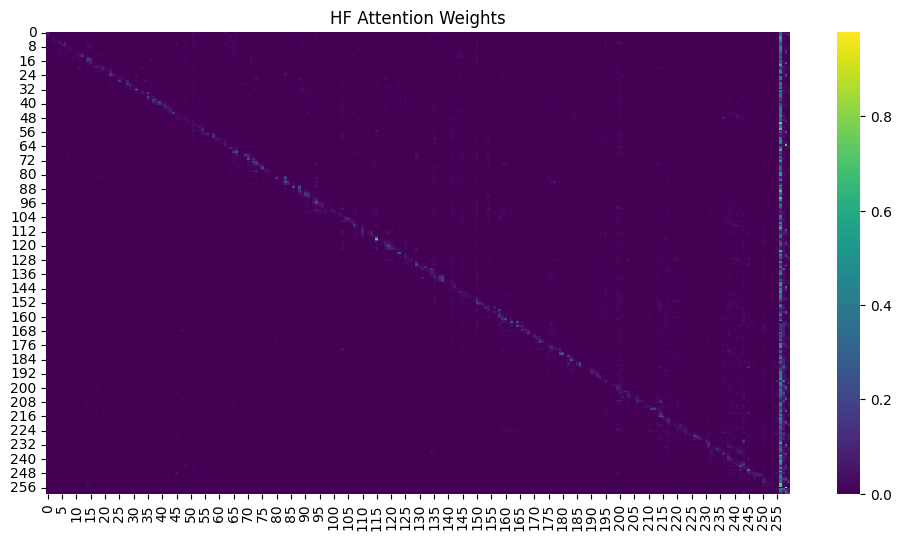

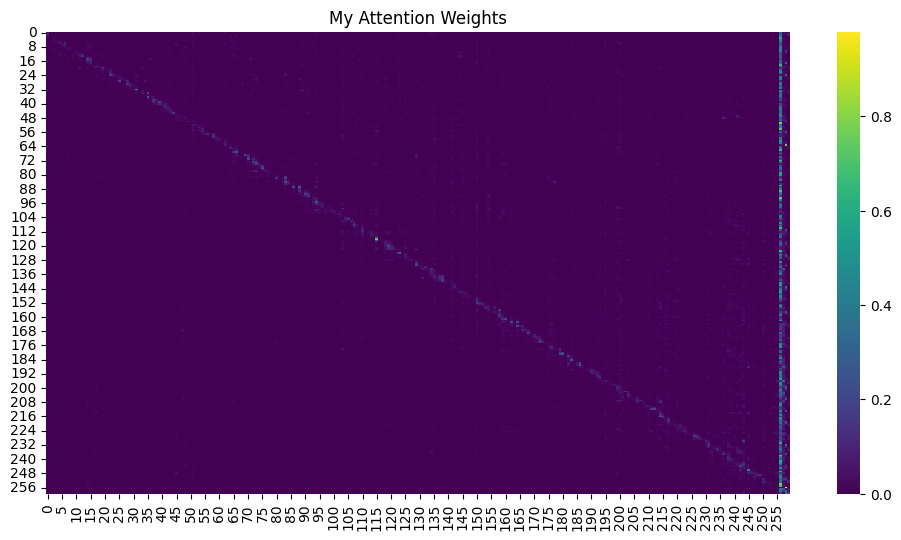

In [19]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plot heatmap for HF attention weights
plt.figure(figsize=(12, 6))
sns.heatmap(attn.squeeze()[0].detach().numpy(), cmap="viridis")
plt.title("HF Attention Weights")
plt.show()

# Plot heatmap for My attention weights
plt.figure(figsize=(12, 6))
sns.heatmap(my_attn.squeeze()[0].detach().numpy(), cmap="viridis")
plt.title("My Attention Weights")
plt.show()

In [20]:
my_attn.squeeze()[0].detach().numpy().sum(axis=-1)

array([0.99999994, 0.99999994, 1.        , 1.        , 1.        ,
       0.99999994, 1.        , 1.        , 1.        , 1.        ,
       0.99999994, 1.        , 1.        , 0.9999999 , 0.99999994,
       1.0000002 , 0.9999999 , 1.        , 1.        , 1.0000001 ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.99999994, 1.        , 1.0000001 , 1.        ,
       1.0000001 , 1.        , 1.        , 0.99999994, 1.        ,
       1.        , 1.        , 0.99999994, 0.99999994, 1.0000001 ,
       1.        , 1.0000001 , 1.        , 1.        , 0.99999994,
       1.0000001 , 1.        , 1.        , 1.0000001 , 0.99999994,
       1.        , 0.9999999 , 1.        , 1.        , 1.        ,
       1.        , 1.        , 0.99999994, 1.        , 1.        ,
       0.9999999 , 1.        , 1.        , 1.        , 1.0000001 ,
       1.        , 1.        , 0.99999994, 1.        , 0.99999994,
       0.99999994, 1.0000001 , 1.        , 1.        , 0.99999

In [21]:
hf_input_embeddings = model.language_model.get_input_embeddings()(inputs["input_ids"])
my_input_embeddings = my_model.language_model.get_input_embeddings()(inputs["input_ids"])

assert hf_input_embeddings.shape == my_input_embeddings.shape


In [22]:
hf_input_embeddings

tensor([[[ 0.3974, -0.0176,  0.0250,  ...,  0.0149,  0.1300,  0.0134],
         [ 0.3974, -0.0176,  0.0250,  ...,  0.0149,  0.1300,  0.0134],
         [ 0.3974, -0.0176,  0.0250,  ...,  0.0149,  0.1300,  0.0134],
         ...,
         [ 0.2183, -0.0271, -0.0802,  ..., -0.1001,  0.0353, -0.0197],
         [ 0.2007, -0.0277, -0.1288,  ...,  0.0135,  0.0164, -0.0741],
         [ 0.2829, -0.0433, -0.2052,  ..., -0.0186,  0.0067, -0.0371]]],
       grad_fn=<EmbeddingBackward0>)

In [23]:
my_input_embeddings

tensor([[[ 0.3974, -0.0176,  0.0250,  ...,  0.0149,  0.1300,  0.0134],
         [ 0.3974, -0.0176,  0.0250,  ...,  0.0149,  0.1300,  0.0134],
         [ 0.3974, -0.0176,  0.0250,  ...,  0.0149,  0.1300,  0.0134],
         ...,
         [ 0.2183, -0.0271, -0.0802,  ..., -0.1001,  0.0353, -0.0197],
         [ 0.2007, -0.0277, -0.1288,  ...,  0.0135,  0.0164, -0.0741],
         [ 0.2829, -0.0433, -0.2052,  ..., -0.0186,  0.0067, -0.0371]]],
       grad_fn=<EmbeddingBackward0>)

In [24]:
assert my_model.language_model.lm_head.weight.equal(model.language_model.model.embed_tokens.weight)

model.language_model.model.embed_tokens.weight

Parameter containing:
tensor([[ 0.5354, -0.0342,  0.0956,  ...,  0.0394,  0.2650,  0.0719],
        [ 0.1616, -0.1613, -0.1451,  ..., -0.0263,  0.0057, -0.0356],
        [ 0.1212,  0.0206, -0.0286,  ..., -0.0060,  0.0020, -0.0056],
        ...,
        [ 0.3976, -0.0175,  0.0251,  ...,  0.0150,  0.1301,  0.0137],
        [ 0.3962, -0.0176,  0.0255,  ...,  0.0143,  0.1294,  0.0136],
        [ 0.3968, -0.0174,  0.0245,  ...,  0.0147,  0.1299,  0.0131]],
       requires_grad=True)

In [25]:
assert my_model.language_model.lm_head.weight.equal(model.language_model.lm_head.weight)

model.language_model.lm_head.weight

Parameter containing:
tensor([[ 0.5354, -0.0342,  0.0956,  ...,  0.0394,  0.2650,  0.0719],
        [ 0.1616, -0.1613, -0.1451,  ..., -0.0263,  0.0057, -0.0356],
        [ 0.1212,  0.0206, -0.0286,  ..., -0.0060,  0.0020, -0.0056],
        ...,
        [ 0.3976, -0.0175,  0.0251,  ...,  0.0150,  0.1301,  0.0137],
        [ 0.3962, -0.0176,  0.0255,  ...,  0.0143,  0.1294,  0.0136],
        [ 0.3968, -0.0174,  0.0245,  ...,  0.0147,  0.1299,  0.0131]],
       requires_grad=True)

In [26]:
my_model.language_model.model.layers[0].self_attn.rotary_emb.inv_freq

tensor([1.0000e+00, 9.3057e-01, 8.6596e-01, 8.0584e-01, 7.4989e-01, 6.9783e-01,
        6.4938e-01, 6.0430e-01, 5.6234e-01, 5.2330e-01, 4.8697e-01, 4.5316e-01,
        4.2170e-01, 3.9242e-01, 3.6517e-01, 3.3982e-01, 3.1623e-01, 2.9427e-01,
        2.7384e-01, 2.5483e-01, 2.3714e-01, 2.2067e-01, 2.0535e-01, 1.9110e-01,
        1.7783e-01, 1.6548e-01, 1.5399e-01, 1.4330e-01, 1.3335e-01, 1.2409e-01,
        1.1548e-01, 1.0746e-01, 1.0000e-01, 9.3057e-02, 8.6596e-02, 8.0584e-02,
        7.4989e-02, 6.9783e-02, 6.4938e-02, 6.0430e-02, 5.6234e-02, 5.2330e-02,
        4.8697e-02, 4.5316e-02, 4.2170e-02, 3.9242e-02, 3.6517e-02, 3.3982e-02,
        3.1623e-02, 2.9427e-02, 2.7384e-02, 2.5483e-02, 2.3714e-02, 2.2067e-02,
        2.0535e-02, 1.9110e-02, 1.7783e-02, 1.6548e-02, 1.5399e-02, 1.4330e-02,
        1.3335e-02, 1.2409e-02, 1.1548e-02, 1.0746e-02, 1.0000e-02, 9.3057e-03,
        8.6596e-03, 8.0584e-03, 7.4989e-03, 6.9783e-03, 6.4938e-03, 6.0430e-03,
        5.6234e-03, 5.2330e-03, 4.8697e-

In [27]:
model.language_model.model.layers[0].self_attn.rotary_emb.inv_freq

tensor([1.0000e+00, 9.3057e-01, 8.6596e-01, 8.0584e-01, 7.4989e-01, 6.9783e-01,
        6.4938e-01, 6.0430e-01, 5.6234e-01, 5.2330e-01, 4.8697e-01, 4.5316e-01,
        4.2170e-01, 3.9242e-01, 3.6517e-01, 3.3982e-01, 3.1623e-01, 2.9427e-01,
        2.7384e-01, 2.5483e-01, 2.3714e-01, 2.2067e-01, 2.0535e-01, 1.9110e-01,
        1.7783e-01, 1.6548e-01, 1.5399e-01, 1.4330e-01, 1.3335e-01, 1.2409e-01,
        1.1548e-01, 1.0746e-01, 1.0000e-01, 9.3057e-02, 8.6596e-02, 8.0584e-02,
        7.4989e-02, 6.9783e-02, 6.4938e-02, 6.0430e-02, 5.6234e-02, 5.2330e-02,
        4.8697e-02, 4.5316e-02, 4.2170e-02, 3.9242e-02, 3.6517e-02, 3.3982e-02,
        3.1623e-02, 2.9427e-02, 2.7384e-02, 2.5483e-02, 2.3714e-02, 2.2067e-02,
        2.0535e-02, 1.9110e-02, 1.7783e-02, 1.6548e-02, 1.5399e-02, 1.4330e-02,
        1.3335e-02, 1.2409e-02, 1.1548e-02, 1.0746e-02, 1.0000e-02, 9.3057e-03,
        8.6596e-03, 8.0584e-03, 7.4989e-03, 6.9783e-03, 6.4938e-03, 6.0430e-03,
        5.6234e-03, 5.2330e-03, 4.8697e-